In [1]:
import pyreadstat

ch, metadata = pyreadstat.read_sav("ch.sav")

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
analysis = ch.copy()

In [4]:
variables = [
    'IM16',
    'windex5',
    'melevel',
    'Zone',
    'HL4',
    'CAGE',
    'chweight',
    'source'
]

analysis = analysis[variables].copy()

In [5]:
analysis.shape

(29335, 8)

In [6]:
analysis.head()

,IM16,windex5,melevel,Zone,HL4,CAGE,chweight,source
0,NaN,5.0,3.0,4.0,1.0,33.0,0.645488,1.0
1,NaN,5.0,3.0,4.0,2.0,14.0,0.645488,1.0
2,NaN,5.0,3.0,4.0,2.0,52.0,0.645488,1.0
3,NaN,5.0,3.0,4.0,2.0,58.0,0.645488,1.0
4,1.0,5.0,3.0,4.0,2.0,34.0,0.645488,1.0


In [7]:
import pandas as pd

In [8]:
pd.crosstab(
    analysis['source'],
    analysis['IM16'],
    dropna=False
)

IM16,1.0,2.0,8.0,9.0,NaN
source,,,,,
1.0,3013,2048,146,14,23357
2.0,237,57,21,2,440


In [9]:
analysis['IM16_present'] = analysis['IM16'].notna()

In [10]:
pd.crosstab(
    analysis['CAGE'],
    analysis['IM16_present']
)

IM16_present,False,True
CAGE,,
0.0,221,20
1.0,459,72
2.0,387,65
3.0,400,98
4.0,439,106
5.0,382,99
6.0,385,103
7.0,393,88
8.0,393,114


In [11]:
nics = analysis[
    (analysis['CAGE'] >= 12) &
    (analysis['CAGE'] <= 23)
].copy()

nics.shape

(6268, 9)

In [12]:
nics = analysis[analysis["CAGE"].between(12, 23)].copy()

print(nics.shape)
print(nics["source"].value_counts(dropna=False))

pd.crosstab(
    nics["source"],
    nics["IM16"],
    dropna=False
)

(6268, 9)
source
1.0    5522
2.0     746
Name: count, dtype: int64


IM16,1.0,2.0,8.0,9.0,NaN
source,,,,,
1.0,1149,621,45,2,3705
2.0,231,57,21,2,435


In [13]:
nics.shape

(6268, 9)

In [14]:
## Create the clean outcome-specific dataset

In [15]:
measles = nics[nics['IM16'].isin([1.0, 2.0])].copy()

In [16]:
measles.shape

(2058, 9)

In [17]:
# Creating binary outcome

In [18]:
measles['measles_vaccinated'] = measles['IM16'].map({
    1.0: 1,
    2.0: 0
})

In [19]:
measles['measles_vaccinated'].value_counts()

measles_vaccinated
1    1380
0     678
Name: count, dtype: int64

In [20]:
# First Statistics

In [21]:
measles['measles_vaccinated'].mean() * 100

np.float64(67.05539358600583)

In [22]:
## Create the final measle outcome dataset

In [23]:
measles = nics[nics['IM16'].isin([1.0, 2.0])].copy()

In [24]:
measles['measles_vaccinated'] = measles['IM16'].map({
    1.0: 1,
    2.0: 0
})

In [25]:
measles.shape

(2058, 10)

In [26]:
measles['measles_vaccinated'].value_counts()

measles_vaccinated
1    1380
0     678
Name: count, dtype: int64

In [27]:
measles['measles_vaccinated'].mean() * 100

np.float64(67.05539358600583)

In [28]:
## First explanatory variable: household wealth

In [29]:
wealth_table = pd.crosstab(
    measles['windex5'],
    measles['measles_vaccinated'],
    normalize='index'
) * 100

wealth_table

measles_vaccinated,0,1
windex5,,
1.0,54.973822,45.026178
2.0,44.844125,55.155875
3.0,29.396985,70.603015
4.0,21.212121,78.787879
5.0,16.898148,83.101852


In [30]:
## Maternal Education

In [31]:
education_table = pd.crosstab(
    measles['melevel'],
    measles['measles_vaccinated'],
    normalize='index'
) * 100

education_table

measles_vaccinated,0,1
melevel,,
1.0,53.145336,46.854664
2.0,28.901734,71.098266
3.0,21.589404,78.410596
4.0,8.482143,91.517857
5.0,55.514706,44.485294


In [32]:
measles['melevel'].value_counts()

melevel
3.0    755
1.0    461
2.0    346
5.0    272
4.0    224
Name: count, dtype: int64

In [33]:
pd.crosstab(
    measles['melevel'],
    measles['measles_vaccinated']
)

measles_vaccinated,0,1
melevel,,
1.0,245,216
2.0,100,246
3.0,163,592
4.0,19,205
5.0,151,121


In [34]:
## Geopolitical zones

In [35]:
zone_table = pd.crosstab(
    measles['Zone'],
    measles['measles_vaccinated'],
    normalize='index'
) * 100

zone_table

measles_vaccinated,0,1
Zone,,
1.0,22.580645,77.419355
2.0,49.275362,50.724638
3.0,52.343750,47.656250
4.0,19.402985,80.597015
5.0,17.689531,82.310469
6.0,26.153846,73.846154


In [36]:
pd.crosstab(
    measles['Zone'],
    measles['measles_vaccinated']
)

measles_vaccinated,0,1
Zone,,
1.0,105,360
2.0,136,140
3.0,268,244
4.0,52,216
5.0,49,228
6.0,68,192


In [37]:
## Sex Variable

In [38]:
sex_table = pd.crosstab(
    measles['HL4'],
    measles['measles_vaccinated'],
    normalize='index'
) * 100

sex_table

measles_vaccinated,0,1
HL4,,
1.0,32.313576,67.686424
2.0,33.596838,66.403162


In [39]:
pd.crosstab(
    measles['HL4'],
    measles['measles_vaccinated']
)

measles_vaccinated,0,1
HL4,,
1.0,338,708
2.0,340,672


In [40]:
# More descriptive analysis for age variable

In [41]:
measles.groupby('CAGE')['measles_vaccinated'].agg(
    ['count', 'mean']
).assign(
    vaccination_rate=lambda x: x['mean'] * 100
)

,count,mean,vaccination_rate
CAGE,,,
12.0,159,0.616352,61.635220
13.0,160,0.543750,54.375000
14.0,200,0.675000,67.500000
15.0,158,0.651899,65.189873
16.0,190,0.689474,68.947368
17.0,184,0.625000,62.500000
18.0,174,0.683908,68.390805
19.0,190,0.689474,68.947368
20.0,177,0.638418,63.841808


In [42]:
## Children sample weight

In [43]:
measles['chweight'].describe()

count    2058.000000
mean        1.028435
std         0.932993
min         0.063406
25%         0.472479
50%         0.764386
75%         1.231420
max         7.290078
Name: chweight, dtype: float64

In [44]:
measles['chweight'].head(10)

9     0.645488
22    0.364121
26    0.364121
29    0.314469
41    0.314469
46    0.463427
48    0.463427
58    0.662039
60    0.662039
67    0.662039
Name: chweight, dtype: float64

In [45]:
measles['chweight'].isna().sum()

np.int64(0)

In [46]:
## Weight overall vacination rate

In [47]:
weighted_rate = (
    (measles['measles_vaccinated'] * measles['chweight']).sum()
    / measles['chweight'].sum()
) * 100

weighted_rate

np.float64(69.32002158287233)

In [48]:
measles['chweight'].sum()

np.float64(2116.519121684876)

In [49]:
## Weight vaccination by wealth

In [50]:
weighted_wealth = (
    measles.groupby('windex5')
    .apply(lambda x: (
        (x['measles_vaccinated'] * x['chweight']).sum()
        / x['chweight'].sum()
    ) * 100)
)

weighted_wealth

windex5
1.0    41.041849
2.0    55.493106
3.0    71.078991
4.0    81.356275
5.0    80.903525
dtype: float64

In [51]:
wealth_weights = measles.groupby('windex5')['chweight'].sum()

wealth_weights

windex5
1.0    295.871420
2.0    362.490445
3.0    382.778305
4.0    549.700283
5.0    525.678667
Name: chweight, dtype: float64

In [52]:
## 12 - 23 Months age analysis

In [53]:
measles_12_23 = measles[
    measles['CAGE'].between(12, 23)
].copy()

In [54]:
measles_12_23.shape

(2058, 10)

In [55]:
measles_12_23['IM16'].value_counts()

IM16
1.0    1380
2.0     678
Name: count, dtype: int64

In [56]:
measles_12_23['CAGE'].describe()

count    2058.000000
mean       17.432945
std         3.375341
min        12.000000
25%        14.000000
50%        17.000000
75%        20.000000
max        23.000000
Name: CAGE, dtype: float64

In [57]:
## 12 - 23 Vaccination rate

In [58]:
weighted_rate = (
    (measles_12_23['IM16'] == 1).astype(int) * measles_12_23['chweight']
).sum() / measles_12_23['chweight'].sum()

weighted_rate * 100

np.float64(69.32002158287233)

In [59]:
# NICS, children aged 12–23 months → weighted measles vaccination rate = 69.32%.

In [60]:
## 12 - 23 Household Wealth rate

In [61]:
wealth_rates = (
    measles_12_23
    .groupby('windex5')
    .apply(lambda x: ((x['IM16'] == 1) * x['chweight']).sum() / x['chweight'].sum() * 100)
)

wealth_rates

windex5
1.0    41.041849
2.0    55.493106
3.0    71.078991
4.0    81.356275
5.0    80.903525
dtype: float64

In [62]:
## 12-23 Marternal Education

In [63]:
education_rates = (
    measles_12_23
    .groupby('melevel')
    .apply(lambda x: ((x['IM16'] == 1) * x['chweight']).sum() / x['chweight'].sum() * 100)
)

education_rates

melevel
1.0    48.100338
2.0    70.528487
3.0    78.010351
4.0    92.619087
5.0    47.518342
dtype: float64

In [64]:
## 12-23 Geographic rate

In [65]:
zone_rates = (
    measles_12_23
    .groupby('Zone')
    .apply(lambda x: ((x['IM16'] == 1) * x['chweight']).sum() / x['chweight'].sum() * 100)
)

zone_rates

Zone
1.0    77.846100
2.0    58.982271
3.0    49.240753
4.0    82.343590
5.0    85.839938
6.0    72.509574
dtype: float64

In [66]:
## Sample size behind these categories

In [67]:
# Sex

In [68]:
sex_rates = (
    measles_12_23
    .groupby('HL4')
    .apply(lambda x: ((x['IM16'] == 1) * x['chweight']).sum() / x['chweight'].sum() * 100)
)

sex_rates

HL4
1.0    70.908658
2.0    67.617413
dtype: float64

In [69]:
# Age

In [70]:
age_rates = (
    measles_12_23
    .groupby('CAGE')
    .apply(lambda x: ((x['IM16'] == 1) * x['chweight']).sum() / x['chweight'].sum() * 100)
)

age_rates

CAGE
12.0    64.665591
13.0    61.821197
14.0    69.684673
15.0    63.962066
16.0    72.590499
17.0    61.500053
18.0    71.801644
19.0    68.776550
20.0    62.656293
21.0    83.768628
22.0    71.368298
23.0    78.282269
dtype: float64

In [71]:
# Sample size with each variable

In [72]:
print("WEALTH")
print(measles_12_23['windex5'].value_counts().sort_index())

print("\nMATERNAL EDUCATION")
print(measles_12_23['melevel'].value_counts().sort_index())

print("\nGEOPOLITICAL ZONE")
print(measles_12_23['Zone'].value_counts().sort_index())

print("\nSEX")
print(measles_12_23['HL4'].value_counts().sort_index())

WEALTH
windex5
1.0    382
2.0    417
3.0    398
4.0    429
5.0    432
Name: count, dtype: int64

MATERNAL EDUCATION
melevel
1.0    461
2.0    346
3.0    755
4.0    224
5.0    272
Name: count, dtype: int64

GEOPOLITICAL ZONE
Zone
1.0    465
2.0    276
3.0    512
4.0    268
5.0    277
6.0    260
Name: count, dtype: int64

SEX
HL4
1.0    1046
2.0    1012
Name: count, dtype: int64


In [73]:
## Visualisation

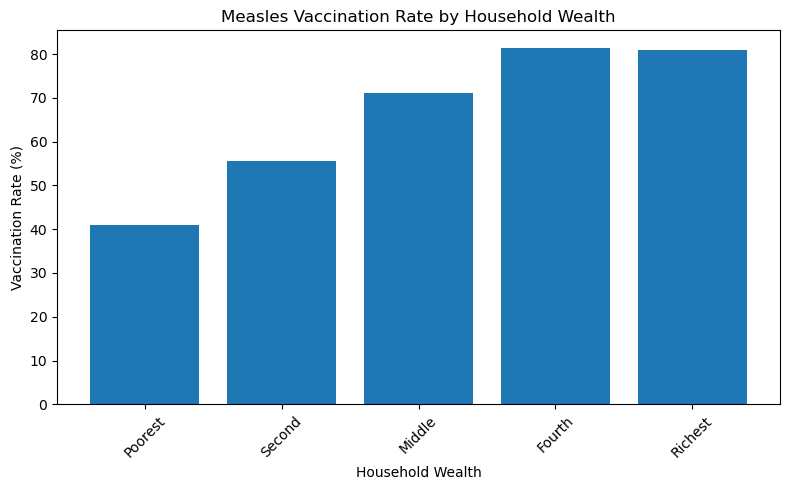

In [85]:
import matplotlib.pyplot as plt

wealth_labels = ['Poorest', 'Second', 'Middle', 'Fourth', 'Richest']

plt.figure(figsize=(8, 5))

plt.bar(wealth_labels, wealth_rates.values)

plt.title('Measles Vaccination Rate by Household Wealth')
plt.xlabel('Household Wealth')
plt.ylabel('Vaccination Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("wealth_vaccination.png", dpi=300)

plt.show()

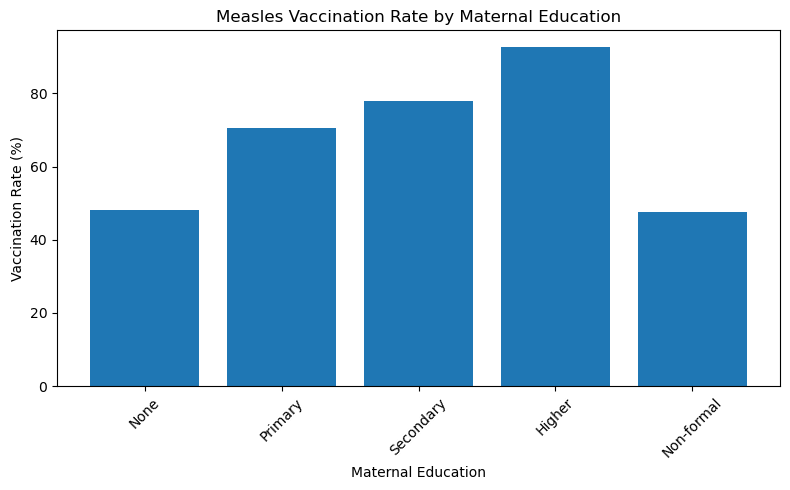

In [86]:
import matplotlib.pyplot as plt

education_labels = ['None', 'Primary', 'Secondary', 'Higher', 'Non-formal']

plt.figure(figsize=(8, 5))

plt.bar(education_labels, education_rates.values)

plt.title('Measles Vaccination Rate by Maternal Education')
plt.xlabel('Maternal Education')
plt.ylabel('Vaccination Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("education_vaccination.png", dpi=300)

plt.show()

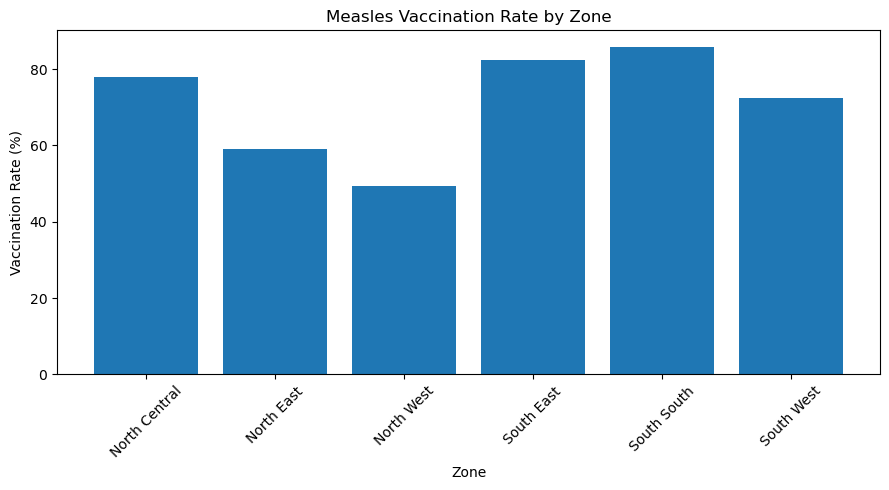

In [87]:
import matplotlib.pyplot as plt

zone_labels = [
    'North Central',
    'North East',
    'North West',
    'South East',
    'South South',
    'South West'
]

plt.figure(figsize=(9, 5))

plt.bar(zone_labels, zone_rates.values)

plt.title('Measles Vaccination Rate by Zone')
plt.xlabel('Zone')
plt.ylabel('Vaccination Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("zone_vaccination.png", dpi=300)

plt.show()